# Deep MLP for Just-In-Time Defect Prediction

Trains a fully-connected deep neural network on the 17 engineered
commit-level features (12 raw metrics + 5 derived features, with
log1p transformation of skewed columns) produced by the
`Preprocessing_v2` pipeline. This is the baseline architecture in the
four-model comparison (MLP, Wide & Deep, TabNet, TabTransformer): it
makes no assumptions about feature structure, learning only weighted
combinations of the input features through stacked dense layers.

**v2 update:** points at `processed_v2` artifacts (feature-engineered,
log-transformed) instead of the v1 `processed` artifacts, and writes
results to a separate `results/mlp_v2` directory so the v1 run is
preserved for comparison.

## 1. Environment Setup

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import json
import random

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt

## 2. Configuration

In [4]:
DATA_DIR = "/content/drive/MyDrive/DL-Assignment/data/processed_v2"
RESULTS_DIR = "/content/drive/MyDrive/DL-Assignment/results/mlp_v2"

RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HIDDEN_DIMS = [128, 64, 32]
DROPOUT = 0.5  # winner of the dropout x seed sweep (more stable + higher AUC than 0.3/0.4/0.6)
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10

# Multiplies the "buggy" class weight on top of sklearn's computed-balanced value.
# 1.0 = balanced weighting as-is (current baseline).
# 1.5 / 2.0 / 3.0 = progressively more weight on Buggy -> pushes recall up, precision down.
# Try each of these and compare against the threshold-search results below; changing this
# and threshold search interact, so re-run the threshold search after changing this.
CLASS_WEIGHT_MULTIPLIER = 1.0

# Candidate decision thresholds swept on the VALIDATION set (never the test set) to find
# the one that maximizes Buggy F1, replacing the old hardcoded 0.75 cutoff.
THRESHOLD_SEARCH_RANGE = np.arange(0.05, 0.96, 0.05)

os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed: int) -> None:
    """Fix random seeds across all libraries for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")

Using device: cpu


## 3. Load Preprocessed Artifacts

Loads the v2 artifacts (feature-engineered, log-transformed, 17
features) produced by `Preprocessing_v2.ipynb`. `INPUT_DIM` is read
directly from the array shape, so the model automatically adapts to
the new feature count without further code changes.

In [5]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))
class_weights = np.load(os.path.join(DATA_DIR, "class_weights.npy"))

# Apply the tunable multiplier on top of the balanced weight (see Configuration cell).
class_weights = class_weights.astype(np.float32).copy()
class_weights[1] *= CLASS_WEIGHT_MULTIPLIER

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")
print(f"Class weights [clean, buggy] (after {CLASS_WEIGHT_MULTIPLIER}x multiplier on buggy): {class_weights}")

INPUT_DIM = X_train.shape[1]

X_train: (52133, 17)  X_val: (24430, 17)  X_test: (30111, 17)
Class weights [clean, buggy] (after 1.0x multiplier on buggy): [0.7051289 1.7187458]


## 4. Dataset and DataLoader Construction

In [6]:
def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    """Wrap numpy arrays into a PyTorch DataLoader."""
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [7]:
train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

## 5. Model Architecture

A feedforward network with three hidden layers (128, 64, 32 units),
ReLU activations, batch normalization, and dropout for
regularization. The output layer produces two logits (clean, buggy).

In [8]:
class DeepMLP(nn.Module):
    """Fully-connected deep neural network for binary commit classification."""

    def __init__(self, input_dim: int, hidden_dims: list[int], dropout: float):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [9]:
model = DeepMLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)
Total parameters: 13,154
Trainable parameters: 13,154


## 6. Loss Function and Optimizer

Cross-entropy loss is weighted by the class weights computed during
preprocessing, penalizing misclassification of the minority (buggy)
class more heavily than the majority (clean) class.

In [10]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

## 7. Training Loop with Early Stopping

Training halts if validation loss does not improve for
`EARLY_STOPPING_PATIENCE` consecutive epochs. The model weights from
the best-performing epoch on the validation set are restored before
final evaluation.

In [11]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
) -> float:
    """Run a single training or evaluation epoch. Pass optimizer=None for eval."""
    is_train = optimizer is not None
    model.train(mode=is_train)

    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [12]:
import time

best_val_loss = float("inf")
epochs_without_improvement = 0
best_state_dict = None

history = {"train_loss": [], "val_loss": []}

start_time = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = run_epoch(model, val_loader, criterion, None, DEVICE)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

training_seconds = time.time() - start_time
print(f"\nTraining time: {training_seconds:.1f} s over {epoch} epochs")

model.load_state_dict(best_state_dict)
print(f"Restored best model with val_loss={best_val_loss:.4f}")

Epoch   1 | train_loss=0.6114 | val_loss=0.5634
Epoch   2 | train_loss=0.5843 | val_loss=0.5569
Epoch   3 | train_loss=0.5746 | val_loss=0.5573
Epoch   4 | train_loss=0.5704 | val_loss=0.5549
Epoch   5 | train_loss=0.5693 | val_loss=0.5516
Epoch   6 | train_loss=0.5671 | val_loss=0.5492
Epoch   7 | train_loss=0.5666 | val_loss=0.5454
Epoch   8 | train_loss=0.5644 | val_loss=0.5484
Epoch   9 | train_loss=0.5631 | val_loss=0.5474
Epoch  10 | train_loss=0.5630 | val_loss=0.5471
Epoch  11 | train_loss=0.5623 | val_loss=0.5473
Epoch  12 | train_loss=0.5615 | val_loss=0.5467
Epoch  13 | train_loss=0.5596 | val_loss=0.5454
Epoch  14 | train_loss=0.5579 | val_loss=0.5437
Epoch  15 | train_loss=0.5582 | val_loss=0.5435
Epoch  16 | train_loss=0.5584 | val_loss=0.5451
Epoch  17 | train_loss=0.5573 | val_loss=0.5416
Epoch  18 | train_loss=0.5558 | val_loss=0.5440
Epoch  19 | train_loss=0.5566 | val_loss=0.5433
Epoch  20 | train_loss=0.5574 | val_loss=0.5428
Epoch  21 | train_loss=0.5556 | val_loss

## 8. Training Curves

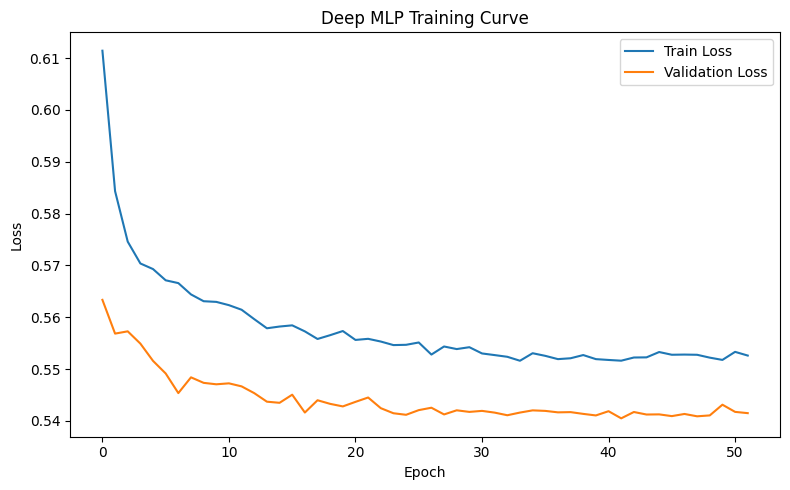

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep MLP Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curve.png"))
plt.show()

## 9. Evaluation

Final evaluation is performed once on the held-out test set
(2017-2019 commits), which was not used for training or
hyperparameter tuning.

In [14]:
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device, threshold: float = 0.5) -> dict:
    """Compute predictions and probabilities for an entire dataloader at the given threshold."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)

            # Probability of Buggy class
            probs = torch.softmax(logits, dim=1)[:, 1]

            preds = (probs >= threshold).long()

            all_labels.extend(y_batch.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

In [15]:
def find_best_threshold(labels: np.ndarray, probs: np.ndarray, thresholds: np.ndarray) -> tuple[float, float]:
    """Sweep decision thresholds and return the one maximizing Buggy F1.

    Must be called on VALIDATION probabilities only, never on the test set,
    to avoid choosing a threshold using the data you'll report metrics on.
    """
    best_threshold, best_f1 = 0.5, -1.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_threshold, best_f1 = t, f1
    return best_threshold, best_f1


In [16]:
# Find the best decision threshold on VALIDATION data (never test), replacing
# the old hardcoded 0.75 cutoff.
val_results = evaluate(model, val_loader, DEVICE, threshold=0.5)
best_threshold, best_val_f1 = find_best_threshold(
    val_results["labels"], val_results["probs"], THRESHOLD_SEARCH_RANGE
)
print(f"Best threshold on validation set: {best_threshold:.2f} (val F1={best_val_f1:.4f})")

# Apply that threshold to the test set for final reporting.
results = evaluate(model, test_loader, DEVICE, threshold=best_threshold)

metrics = {
    "threshold": best_threshold,
    "accuracy": accuracy_score(results["labels"], results["preds"]),
    "precision": precision_score(results["labels"], results["preds"]),
    "recall": recall_score(results["labels"], results["preds"]),
    "f1": f1_score(results["labels"], results["preds"]),
    "macro_f1": f1_score(results["labels"], results["preds"], average="macro"),
    "roc_auc": roc_auc_score(results["labels"], results["probs"]),
    "pr_auc": average_precision_score(results["labels"], results["probs"]),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}" if isinstance(value, float) else f"{name:10s}: {value}")


Best threshold on validation set: 0.50 (val F1=0.6170)
threshold : 0.5000
accuracy  : 0.6669
precision : 0.3431
recall    : 0.7919
f1        : 0.4788
macro_f1  : 0.6170
roc_auc   : 0.7908
pr_auc    : 0.4863


In [17]:
print(classification_report(
    results["labels"], results["preds"], target_names=["Clean", "Buggy"]
))

              precision    recall  f1-score   support

       Clean       0.93      0.64      0.76     24293
       Buggy       0.34      0.79      0.48      5818

    accuracy                           0.67     30111
   macro avg       0.64      0.71      0.62     30111
weighted avg       0.81      0.67      0.70     30111



## 10. Confusion Matrix

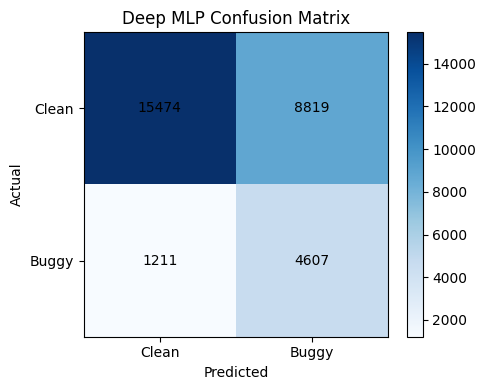

In [18]:
cm = confusion_matrix(results["labels"], results["preds"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Clean", "Buggy"])
ax.set_yticklabels(["Clean", "Buggy"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Deep MLP Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))
plt.show()

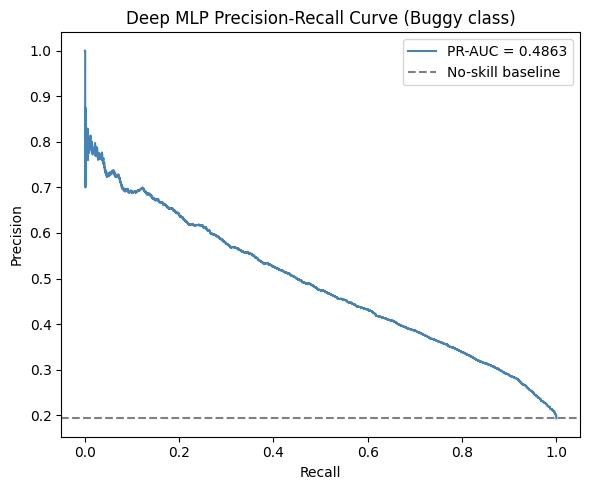

In [19]:
precisions, recalls, pr_thresholds = precision_recall_curve(results["labels"], results["probs"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions, color="steelblue", label=f"PR-AUC = {metrics['pr_auc']:.4f}")
ax.axhline(y=results["labels"].mean(), color="gray", linestyle="--", label="No-skill baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Deep MLP Precision-Recall Curve (Buggy class)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pr_curve.png"))
plt.show()


## 11. Persist Model and Results

The trained weights, evaluation metrics, and training history are
saved for later comparison against the other three architectures.

In [20]:
torch.save(model.state_dict(), os.path.join(RESULTS_DIR, "mlp_weights.pt"))

with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

with open(os.path.join(RESULTS_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

print(f"Model, metrics, and history saved to {RESULTS_DIR}")

Model, metrics, and history saved to /content/drive/MyDrive/DL-Assignment/results/mlp_v2


## 12. Dropout × Seed Robustness Sweep

Manual single runs suggested dropout 0.4-0.5 outperforms 0.3 (the
original default) and 0.6 on Buggy-class F1 and macro F1. This section
confirms that with repeated runs rather than one seed per setting.

**Assignment-brief compliance:** *"All preprocessing and
hyperparameter-tuning decisions must be made using only the training
and validation data. The test dataset must remain unseen and must be
used only for the final evaluation."* Accordingly, each run below
computes `val_f1` / `val_macro_f1` on the validation set — THAT is
what decides the winning dropout. Test-set metrics are also logged for
completeness, but only as a check, never as the basis for choosing a
config. Once you have the recommended dropout from the aggregation
cell, set it in the Configuration cell and re-run the single-run
pipeline (sections 5-11) once for your one official, reportable
test-set result.

In [21]:
import pandas as pd

SWEEP_DROPOUTS = [0.4, 0.5]
SWEEP_SEEDS = [42, 123, 2024]

print(f"Sweep: {len(SWEEP_DROPOUTS)} dropout settings x {len(SWEEP_SEEDS)} seeds = "
      f"{len(SWEEP_DROPOUTS) * len(SWEEP_SEEDS)} runs")

Sweep: 2 dropout settings x 3 seeds = 6 runs


In [22]:
def train_and_evaluate(dropout: float, seed: int, verbose: bool = False) -> dict:
    """Train a fresh DeepMLP with the given dropout/seed and evaluate on the test set."""
    set_seed(seed)

    run_model = DeepMLP(INPUT_DIM, HIDDEN_DIMS, dropout).to(DEVICE)
    run_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    run_optimizer = torch.optim.Adam(run_model.parameters(), lr=LEARNING_RATE)
    run_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        run_optimizer, mode="min", factor=0.5, patience=5
    )

    best_val_loss = float("inf")
    epochs_without_improvement = 0
    best_state_dict = None

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(run_model, train_loader, run_criterion, run_optimizer, DEVICE)
        val_loss = run_epoch(run_model, val_loader, run_criterion, None, DEVICE)
        run_scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = {k: v.clone() for k, v in run_model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            break

    run_model.load_state_dict(best_state_dict)

    # Search the threshold on validation probabilities, then apply it to the test set.
    run_val_results = evaluate(run_model, val_loader, DEVICE, threshold=0.5)
    run_threshold, _ = find_best_threshold(
        run_val_results["labels"], run_val_results["probs"], THRESHOLD_SEARCH_RANGE
    )
    run_val_preds = (run_val_results["probs"] >= run_threshold).astype(int)
    val_f1 = f1_score(run_val_results["labels"], run_val_preds, zero_division=0)
    val_macro_f1 = f1_score(run_val_results["labels"], run_val_preds, average="macro", zero_division=0)

    # Test set touched ONLY here, after every tuning decision (dropout, threshold) is already
    # locked in from validation data — this is what the assignment brief requires.
    run_results = evaluate(run_model, test_loader, DEVICE, threshold=run_threshold)

    metrics = {
        "dropout": dropout,
        "seed": seed,
        "epochs_trained": epoch,
        "best_val_loss": best_val_loss,
        "threshold": run_threshold,
        "val_f1": val_f1,
        "val_macro_f1": val_macro_f1,
        "accuracy": accuracy_score(run_results["labels"], run_results["preds"]),
        "precision": precision_score(run_results["labels"], run_results["preds"]),
        "recall": recall_score(run_results["labels"], run_results["preds"]),
        "f1": f1_score(run_results["labels"], run_results["preds"]),
        "macro_f1": f1_score(run_results["labels"], run_results["preds"], average="macro"),
        "roc_auc": roc_auc_score(run_results["labels"], run_results["probs"]),
        "pr_auc": average_precision_score(run_results["labels"], run_results["probs"]),
    }

    if verbose:
        print(f"  dropout={dropout} seed={seed:5d} | epochs={epoch:3d} | "
              f"F1={metrics['f1']:.4f} | macro_F1={metrics['macro_f1']:.4f}")

    return metrics

In [23]:
sweep_results = []

for dropout in SWEEP_DROPOUTS:
    print(f"Dropout = {dropout}")
    for seed in SWEEP_SEEDS:
        metrics = train_and_evaluate(dropout, seed, verbose=True)
        sweep_results.append(metrics)

sweep_df = pd.DataFrame(sweep_results)
sweep_df

Dropout = 0.4
  dropout=0.4 seed=   42 | epochs= 38 | F1=0.4743 | macro_F1=0.6103
  dropout=0.4 seed=  123 | epochs= 41 | F1=0.4792 | macro_F1=0.6257
  dropout=0.4 seed= 2024 | epochs= 25 | F1=0.4689 | macro_F1=0.6011
Dropout = 0.5
  dropout=0.5 seed=   42 | epochs= 52 | F1=0.4788 | macro_F1=0.6170
  dropout=0.5 seed=  123 | epochs= 33 | F1=0.4867 | macro_F1=0.6343
  dropout=0.5 seed= 2024 | epochs= 28 | F1=0.4838 | macro_F1=0.6307


,dropout,seed,epochs_trained,best_val_loss,threshold,val_f1,val_macro_f1,accuracy,precision,recall,f1,macro_f1,roc_auc,pr_auc
0,0.4,42,38,0.539290,0.50,0.617761,0.706034,0.657866,0.337277,0.798728,0.474280,0.610350,0.790117,0.483569
1,0.4,123,41,0.539467,0.55,0.617141,0.715083,0.683039,0.351055,0.754727,0.479210,0.625704,0.786445,0.480858
2,0.4,2024,25,0.539530,0.45,0.615048,0.696995,0.644980,0.329769,0.811103,0.468899,0.601138,0.783207,0.474638
3,0.5,42,52,0.540506,0.50,0.617040,0.705415,0.666899,0.343140,0.791853,0.478799,0.617017,0.790828,0.486281
4,0.5,123,33,0.539854,0.55,0.618312,0.716412,0.693932,0.360026,0.751117,0.486745,0.634349,0.788975,0.480541
5,0.5,2024,28,0.541806,0.55,0.614653,0.711862,0.689084,0.356145,0.754039,0.483789,0.630670,0.788179,0.482189


### Aggregated Results (mean ± std across seeds)

In [24]:
agg = sweep_df.groupby("dropout")[
    ["val_f1", "val_macro_f1", "accuracy", "precision", "recall", "f1", "macro_f1", "roc_auc", "pr_auc", "threshold"]
].agg(["mean", "std"])
agg = agg.round(4)
print(agg)

print("\n--- SELECTION metrics (validation — use these to pick the config) ---")
for dropout in SWEEP_DROPOUTS:
    subset = sweep_df[sweep_df["dropout"] == dropout]
    print(f"dropout={dropout}: val_F1 = {subset['val_f1'].mean():.4f} ± {subset['val_f1'].std():.4f}  "
          f"| val_macro_F1 = {subset['val_macro_f1'].mean():.4f} ± {subset['val_macro_f1'].std():.4f}")

best_dropout = sweep_df.groupby("dropout")["val_macro_f1"].mean().idxmax()
print(f"\n>>> Recommended final dropout (highest mean val_macro_f1): {best_dropout}")
print(">>> Set DROPOUT to this value in the Configuration cell above, then re-run cells 5 onward")
print(">>> for the ONE final test-set evaluation that goes in your report.")

print("\n--- REPORTING-ONLY metrics (test — do not use these to choose a config) ---")
for dropout in SWEEP_DROPOUTS:
    subset = sweep_df[sweep_df["dropout"] == dropout]
    print(f"dropout={dropout}: F1 = {subset['f1'].mean():.4f} ± {subset['f1'].std():.4f}  "
          f"| macro_F1 = {subset['macro_f1'].mean():.4f} ± {subset['macro_f1'].std():.4f}")

         val_f1         val_macro_f1         accuracy         precision  \
           mean     std         mean     std     mean     std      mean   
dropout                                                                   
0.4      0.6166  0.0014       0.7060  0.0090   0.6620  0.0194    0.3394   
0.5      0.6167  0.0019       0.7112  0.0055   0.6833  0.0144    0.3531   

                 recall              f1         macro_f1         roc_auc  \
            std    mean     std    mean     std     mean     std    mean   
dropout                                                                    
0.4      0.0108  0.7882  0.0296  0.4741  0.0052   0.6124  0.0124  0.7866   
0.5      0.0088  0.7657  0.0227  0.4831  0.0040   0.6273  0.0091  0.7893   

                 pr_auc         threshold          
            std    mean     std      mean     std  
dropout                                            
0.4      0.0035  0.4797  0.0046    0.5000  0.0500  
0.5      0.0014  0.4830  0.0030    

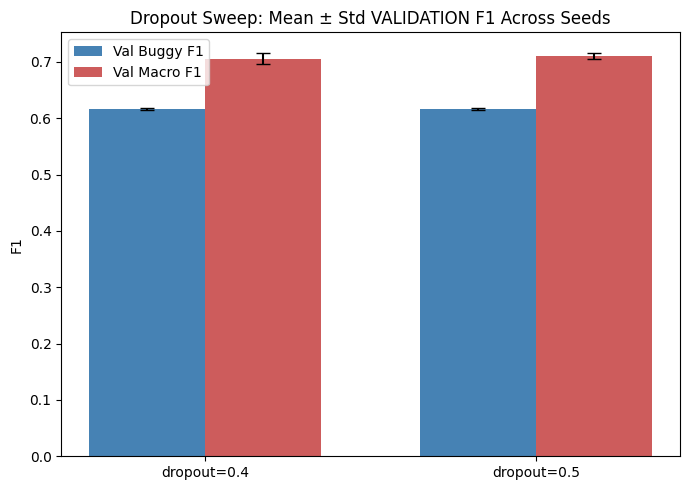

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))

means = sweep_df.groupby("dropout")["val_f1"].mean()
stds = sweep_df.groupby("dropout")["val_f1"].std()
macro_means = sweep_df.groupby("dropout")["val_macro_f1"].mean()
macro_stds = sweep_df.groupby("dropout")["val_macro_f1"].std()

x = np.arange(len(SWEEP_DROPOUTS))
width = 0.35

ax.bar(x - width / 2, means, width, yerr=stds, capsize=5, label="Val Buggy F1", color="steelblue")
ax.bar(x + width / 2, macro_means, width, yerr=macro_stds, capsize=5, label="Val Macro F1", color="indianred")

ax.set_xticks(x)
ax.set_xticklabels([f"dropout={d}" for d in SWEEP_DROPOUTS])
ax.set_ylabel("F1")
ax.set_title("Dropout Sweep: Mean ± Std VALIDATION F1 Across Seeds")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dropout_sweep.png"))
plt.show()

In [26]:
sweep_df.to_csv(os.path.join(RESULTS_DIR, "dropout_sweep_results.csv"), index=False)
print(f"Sweep results saved to {os.path.join(RESULTS_DIR, 'dropout_sweep_results.csv')}")

Sweep results saved to /content/drive/MyDrive/DL-Assignment/results/mlp_v2/dropout_sweep_results.csv


### Reading the sweep

- **Use `val_f1`/`val_macro_f1` to decide, not `f1`/`macro_f1`.** The
  latter are test-set numbers, shown for your own sanity-checking only
  — using them to pick a config is exactly the test-set leakage the
  assignment brief prohibits.
- If val_f1 for 0.4 and 0.5 are within roughly one std of each other,
  treat them as statistically indistinguishable and pick based on the
  precision/recall trade-off that matters for your use case.
- The recommended dropout is printed automatically (highest mean
  `val_macro_f1`). Set `DROPOUT` to that value in the Configuration
  cell, then re-run sections 5-11 for your final, one-time test
  evaluation — that single run's numbers are what goes in your
  report.
- Once dropout is locked, try `CLASS_WEIGHT_MULTIPLIER` at 1.5 / 2.0 /
  3.0 the same way: compare `val_f1`/`val_macro_f1` across values, not
  test metrics, before picking one.

## Summary

| Artifact | Description |
|---|---|
| `mlp_weights.pt` | Trained model state dict (best validation epoch) |
| `metrics.json` | Test-set accuracy, precision, recall, F1, ROC-AUC |
| `history.json` | Per-epoch train/validation loss |
| `training_curve.png` | Loss curve plot |
| `confusion_matrix.png` | Test-set confusion matrix |\n| `dropout_sweep_results.csv` | Per-run metrics for every dropout × seed combination |\n| `dropout_sweep.png` | Mean ± std F1 / macro F1 bar chart across dropout settings |
| `pr_curve.png` | Precision-recall curve and PR-AUC for the single-run model |